## Objectives

The objective of the final project will be to build a fully reproducible project that uses ML to address a question of your choice (e.g. in academic or industry).The dataset required for this project is provided along with this document (see details below). This is an individual project. Since this course is an advanced undergraduate/graduate student level course, it is expected that the final report should be publishable and fully reproducible.

The deliverable of this project is a folder with all the following components:

1. A README file (text file) to briefly introduce the project idea and how it is organized.
2. Well documented Python code to read, explore, and clean data; all processes should be automated and no hand edit on raw data
3. Well documented Python code to manipulate, wrangle, visualize data. Well documented Python code to run ML models and make publication-worthy figures or tables
4. Final report should be submitted in PDF. This file should be structured with Introduction, Methods and Materials, Results, Discussion, and Conclusions (see below). We should be able to reproduce your workflow and regenerate your final report.

## Domain: Banking

Context: This data set contains historical data of the customers who have taken loans from a German bank and the bank is facing issues with loan defaulters. The bank intends to build a machine learning model to predict whether the customer will default or not based on historical data

## Dataset - German_bank.csv

Data Description: The bank has historical information on relevant features for each customer such as employment duration, existing loans count, saving balance, percentage of income, age, default status. 

The data set has 17 columns and 1000 rows. Columns are described below and each row is a customer. 

* **checking_balance - Amount of money available in account of customers**
* **months_loan_duration - Duration since loan taken**
* **credit_history - credit history of each customers**
* **purpose - Purpose why loan has been taken**
* **amount - Amount of loan taken**
* **savings_balance - Balance in account**
* **employment_duration - Duration of employment**
* **percent_of_income - Percentage of monthly income**
* **years_at_residence - Duration of current residence**
* **age - Age of customer**
* **other_credit - Any other credits taken**
* **housing- Type of housing, rent or own**
* **existing_loans_count - Existing count of loans**
* **job - Job type**
* **dependents - Any dependents on customer**
* **phone - Having phone or not**
* **default - Default status (Target column)**

## Import required packages and Load the dataset

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
org = pd.read_csv('./credit.csv')

org.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [43]:
df = org.copy()

## Exploratory Data Analysis or Visualizing Data

In [44]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


**There are 7 integer(numerical) columns and 10 categorical columns. The task is to model the variable 'default' using other predictors.**

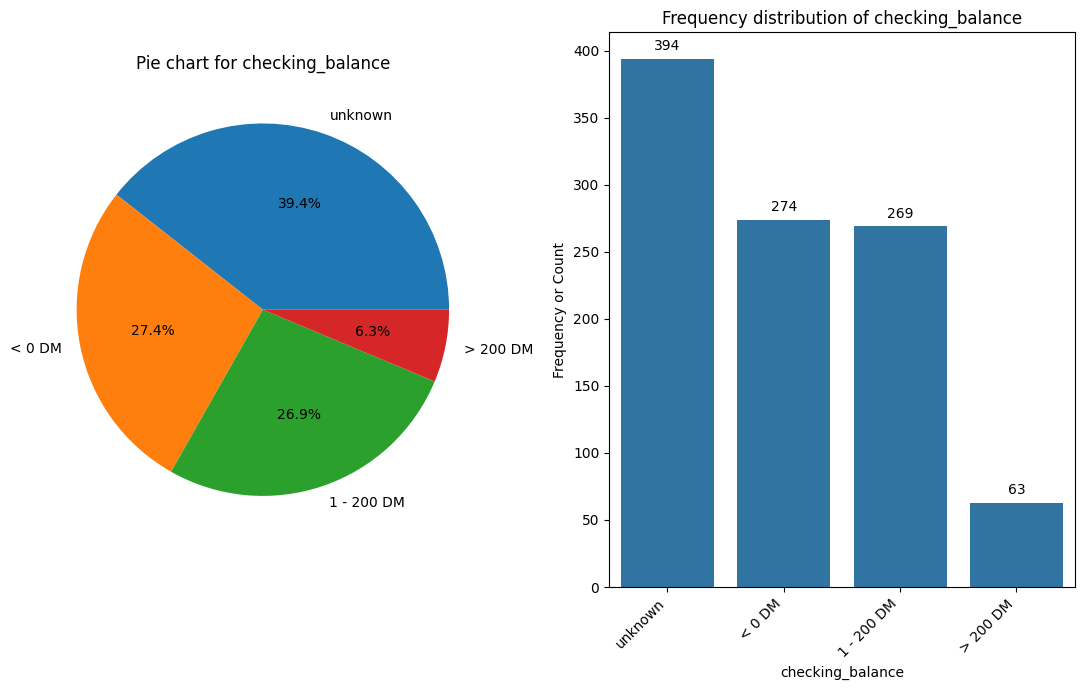

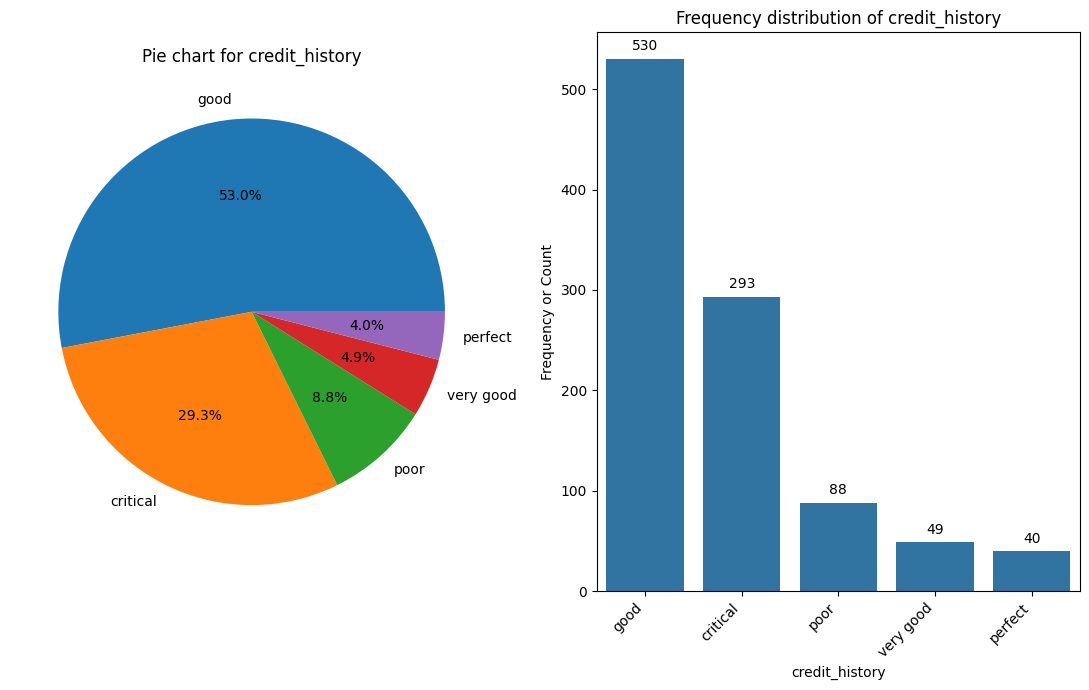

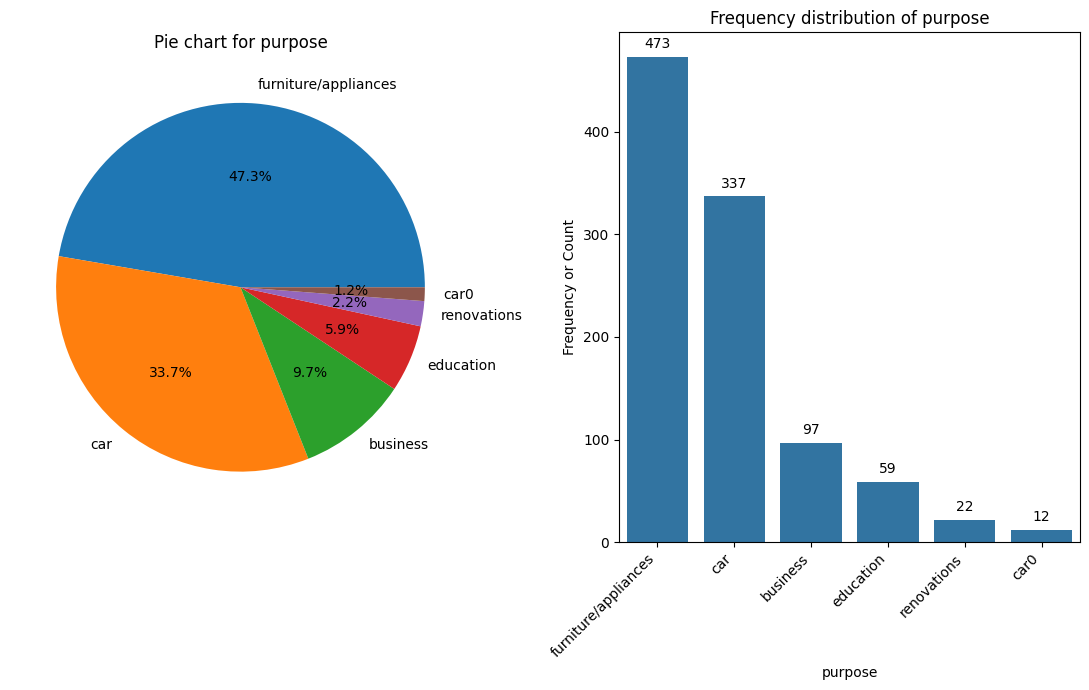

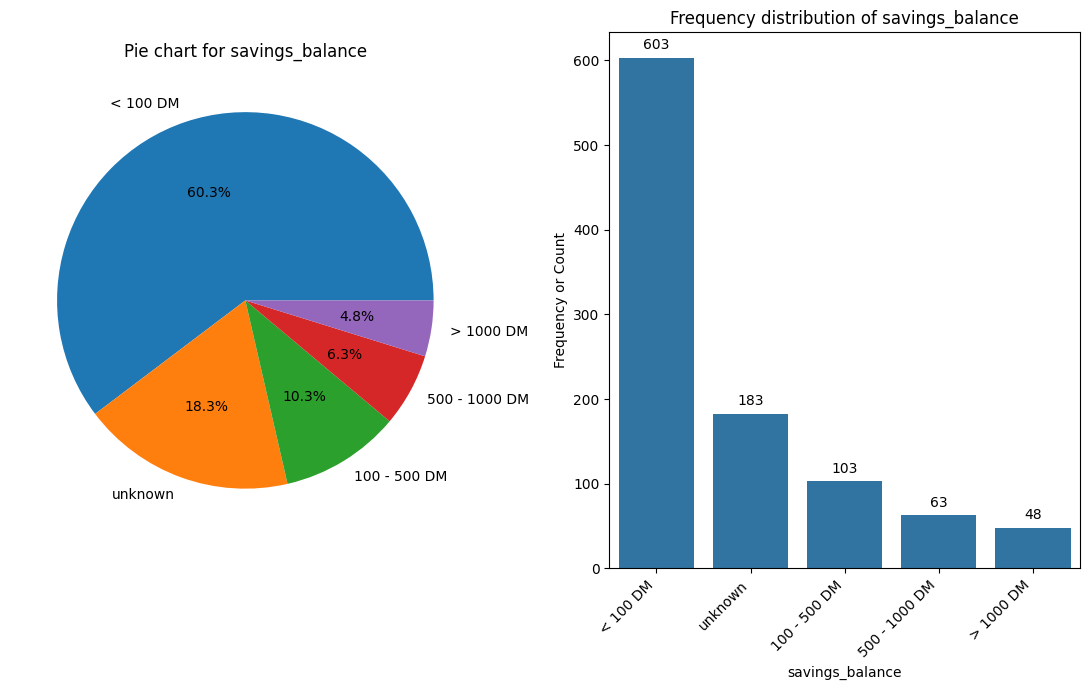

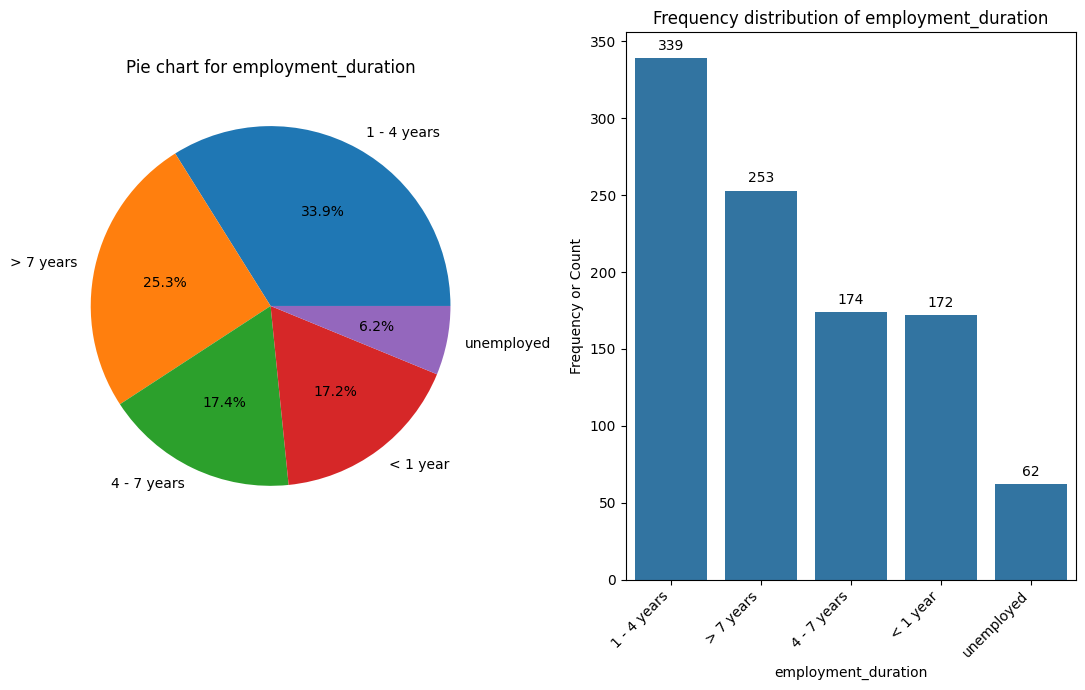

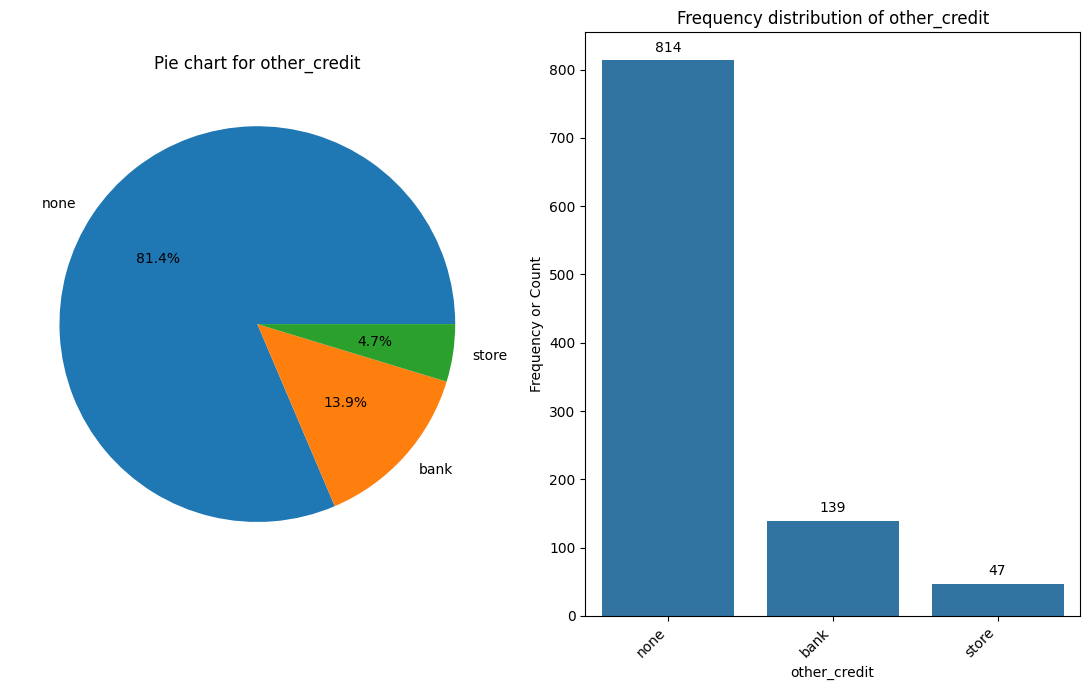

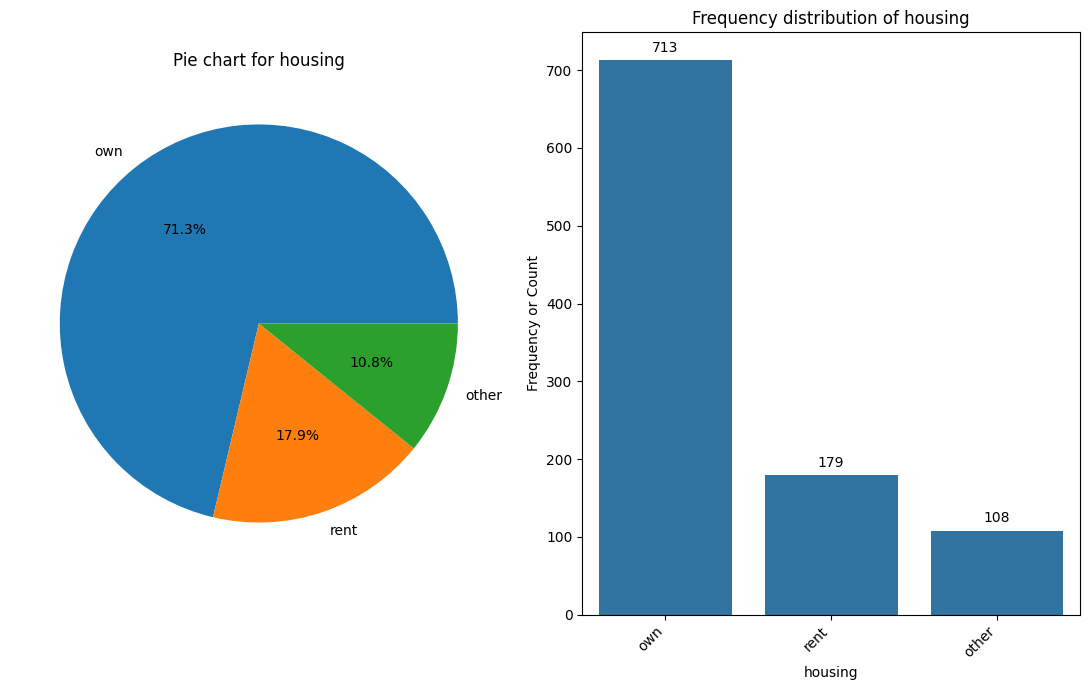

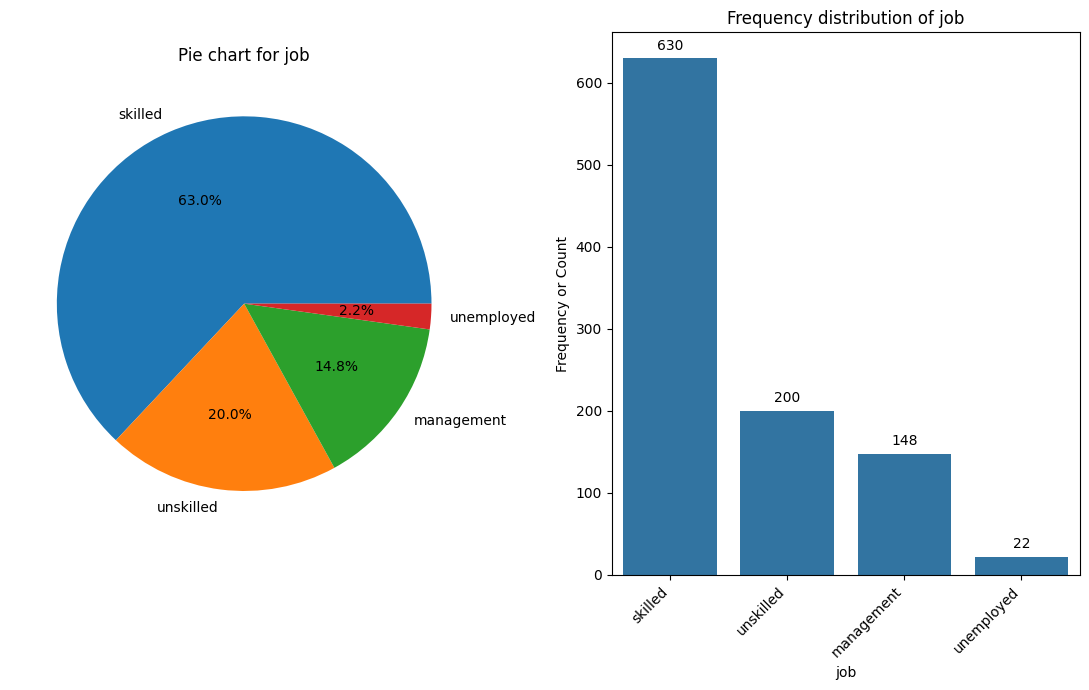

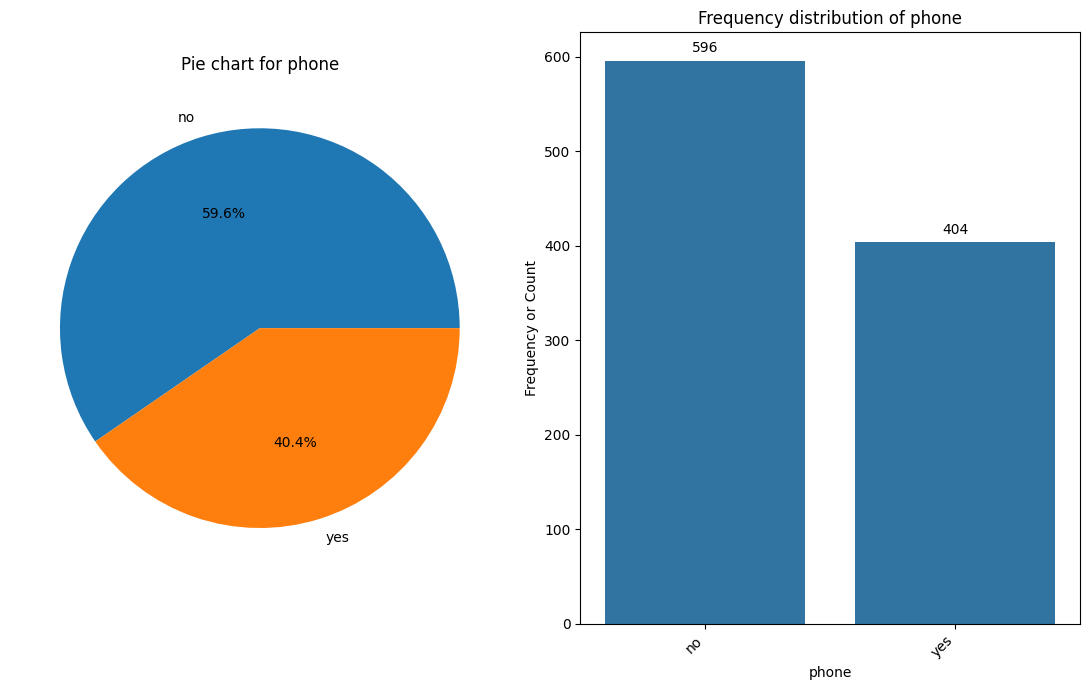

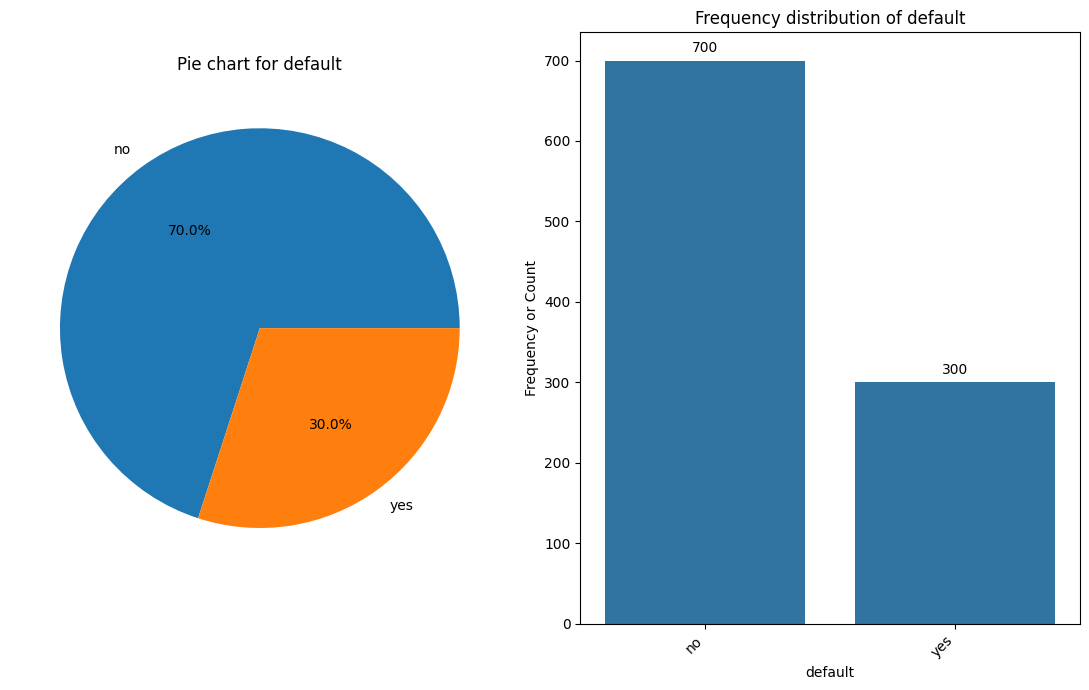

In [75]:
for col in df.columns:
    if df[col].dtype=='O': ## picking categorical columns only
        #print(f'Unique values in {col} =',df[col].unique(),'\n')

        fig, axes = plt.subplots(1, 2, figsize=(11, 7))
        value_counts = df[col].value_counts()
        #print(value_counts)
        
        axes[0].pie(value_counts,labels=value_counts.index, autopct="%1.1f%%")
        axes[0].set_title(f'Pie chart for {col}')

        # Barplot or frequency plot
        sns.countplot(x = col, data =df, ax=axes[1],order=value_counts.index)
        axes[1].set_title(f'Frequency distribution of {col}')
        plt.ylabel('Frequency or Count')
        plt.xticks(rotation=45,ha='right')

        #display frequency on top of each bar
        for p in axes[1].patches:
            axes[1].annotate(format(p.get_height(), '.0f'), 
                              (p.get_x() + p.get_width() / 2., p.get_height()), 
                              ha = 'center', va = 'center', 
                              xytext = (0, 9), 
                              textcoords = 'offset points')
        
        plt.tight_layout()
        plt.show()

## Pre-processing data for model training

## Training and Testing different models

## Observations and Conclusions